<a href="https://colab.research.google.com/github/paulogkl/projeto-integrador-7-trimestre/blob/main/projeto_integrador_7_trimestre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carregando a base Tips diretamente da internet
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

# Vendo as 5 primeiras linhas
print("--- Primeiras 5 linhas ---")
display(df.head())

# Vendo o tamanho da base e os tipos de dados
print("\n--- Informações da base ---")
df.info()

# Vendo as estatísticas básicas (média, desvio padrão, min, max)
print("\n--- Estatísticas Descritivas ---")
display(df.describe())

--- Primeiras 5 linhas ---


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4



--- Informações da base ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB

--- Estatísticas Descritivas ---


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


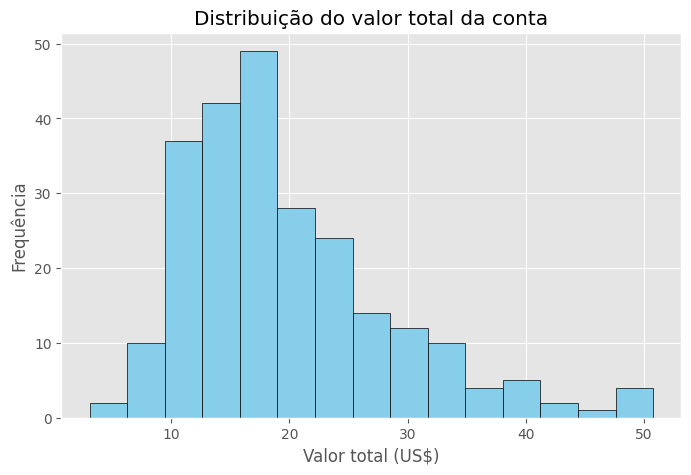

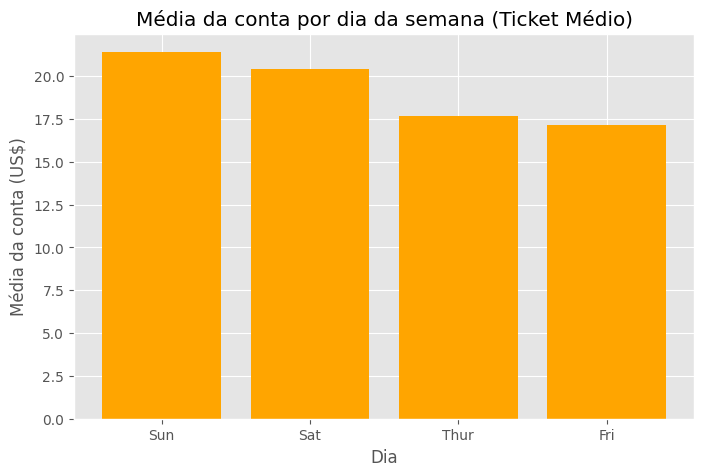

<Figure size 800x500 with 0 Axes>

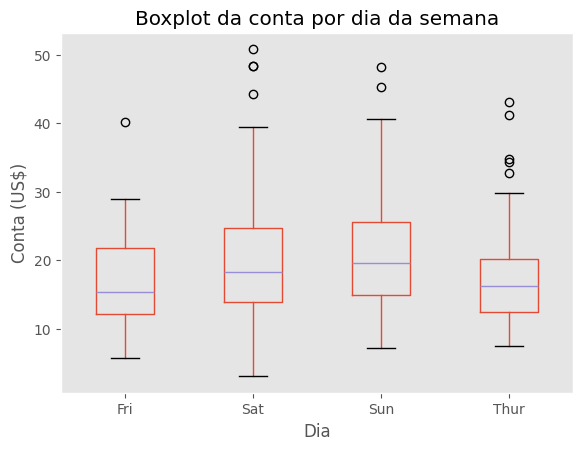

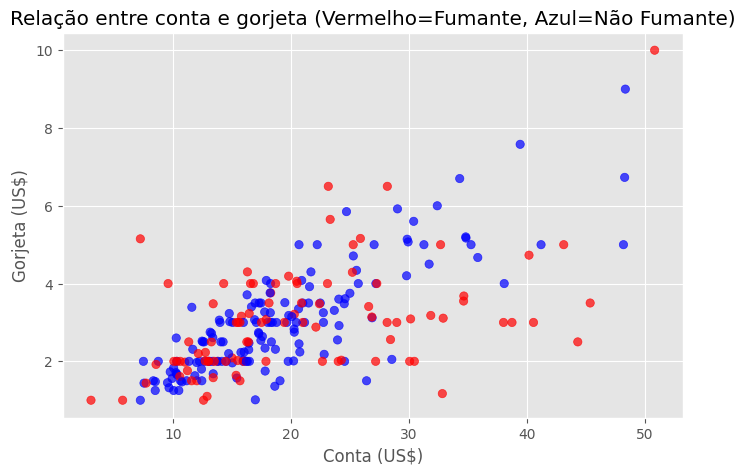

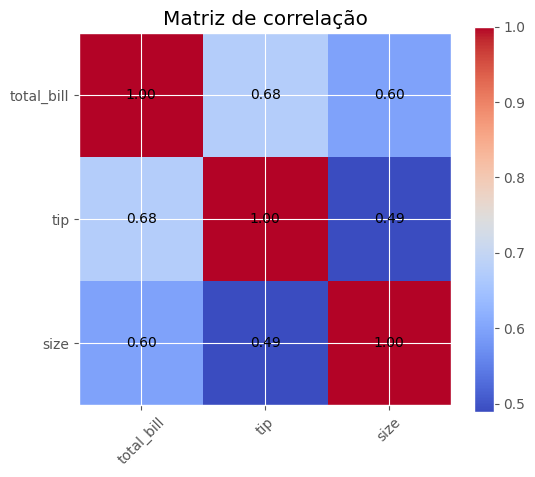

In [2]:
# ==========================================
# 5 VISUALIZAÇÕES PARA A 1ª ENTREGA
# ==========================================

# Configurando o estilo dos gráficos
plt.style.use('ggplot')

# --- Visualização 1: Histograma ---
plt.figure(figsize=(8,5))
plt.hist(df['total_bill'], bins=15, color='skyblue', edgecolor='black')
plt.title('Distribuição do valor total da conta')
plt.xlabel('Valor total (US$)')
plt.ylabel('Frequência')
plt.show()

# --- Visualização 2: Barras (Ticket Médio por Dia) ---
media_dia = df.groupby('day')['total_bill'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
plt.bar(media_dia.index, media_dia.values, color='orange')
plt.title('Média da conta por dia da semana (Ticket Médio)')
plt.xlabel('Dia')
plt.ylabel('Média da conta (US$)')
plt.show()

# --- Visualização 3: Boxplot ---
plt.figure(figsize=(8,5))
df.boxplot(column='total_bill', by='day', grid=False)
plt.title('Boxplot da conta por dia da semana')
plt.suptitle('') # Remove o título automático do Pandas
plt.xlabel('Dia')
plt.ylabel('Conta (US$)')
plt.show()

# --- Visualização 4: Dispersão ---
cores = df['smoker'].map({'Yes':'red', 'No':'blue'})
plt.figure(figsize=(8,5))
plt.scatter(df['total_bill'], df['tip'], c=cores, alpha=0.7)
plt.title('Relação entre conta e gorjeta (Vermelho=Fumante, Azul=Não Fumante)')
plt.xlabel('Conta (US$)')
plt.ylabel('Gorjeta (US$)')
plt.show()

# --- Visualização 5: Heatmap de correlação ---
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Matriz de correlação')

# Adicionando os valores dentro dos quadrados
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black')

plt.show()